<a href="https://colab.research.google.com/github/Yvonneamg/Modelling-the-epidemiologic-evolution-of-Diabetes-Mellitus-Integrating-Physiological-Agent-models/blob/main/UpdatedHybridModeltodate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Step 1: Load the required libraries**

In [1]:
# load the required libraries
!pip install jax jaxlib diffrax numpyro pyreadstat scipy matplotlib pandas
import scipy
import jax # For high performance numerical computing and automatic differentiation
import jax.numpy as jnp
import time
import scipy
import scipy.stats
import jax.random as random
from jax import debug
from scipy import optimize
from scipy.stats import lognorm
from scipy.stats import multivariate_normal
from sklearn.metrics import roc_curve, auc
import pyreadstat
import pandas as pd # For data handling
import numpy as np # For data handling
from jax import jit, vmap
from jax.experimental.ode import odeint
from scipy.optimize import differential_evolution
from jax.scipy.special import logsumexp
import diffrax # For solving ODES
import math
from functools import partial
import matplotlib.pyplot as plt # For visualization
import matplotlib as mpl
from collections import defaultdict
import gc
import os
from datetime import datetime
import pickle
import numpyro # For probablistic modeling to be implemented later
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer import SVI, Trace_ELBO, init_to_median
import time
from tqdm import tqdm
import optax
print("Setup complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.0/388.0 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 5.1 MB/s eta 0:00:00
Setup complete!


#**Step 2: Global Figure Saver**

In [2]:
# ============================================================================
# GLOBAL FIGURE SAVER
# ============================================================================

# Folder to store plots
PLOT_OUTPUT_DIR = "diabetes_plots"
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

def save_figure(fig, name_prefix):
    """
    Save a matplotlib figure safely with timestamp.
    """

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    filename = f"{name_prefix}_{timestamp}.png"

    filepath = os.path.join(PLOT_OUTPUT_DIR, filename)

    fig.savefig(filepath, dpi=300, bbox_inches='tight')

    print(f"Saved: {filename}")

#**Step 3: Load the datasets**

In [27]:
# ============================================================================
# LOAD NHANES DATA FILES FROM GOOGLE DRIVE
# ============================================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# File paths
file_path = "/content/drive/MyDrive/Colab Notebooks/PAXRAW_C.xpt"
demo_path = "/content/drive/MyDrive/Colab Notebooks/2003-2004/DEMO_C.xpt"
gluc_path = "/content/drive/MyDrive/Colab Notebooks/2003-2004/L10AM_C.xpt"
DR1TOT_C = "/content/drive/MyDrive/Colab Notebooks/Datasets/DR1TOT_C.xpt"

# Load datasets
demo_df = pd.read_sas(demo_path)
gluc_df = pd.read_sas(gluc_path)
dr1tot_df = pd.read_sas(DR1TOT_C)

# Quick verification
print("Datasets loaded successfully\n")


print("DEMO_C shape:", demo_df.shape)
print("GLUC_C shape:", gluc_df.shape)
print("DR1TOT_C shape:", dr1tot_df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datasets loaded successfully

DEMO_C shape: (10122, 44)
GLUC_C shape: (3356, 7)
DR1TOT_C shape: (9643, 160)


# **Step 4: Reproduce De Gaetano Physiological Model.**

[5.0e+00 1.0e+03 3.5e+01 1.0e-03 1.0e-02 1.8e+01]
Simulation completed
Base:4.344109058380127
Base:0.0022094249725341797
Base:0.007553815841674805
Base:0.0064504146575927734
Saved: physiological_model_validation_20260408_091418.png


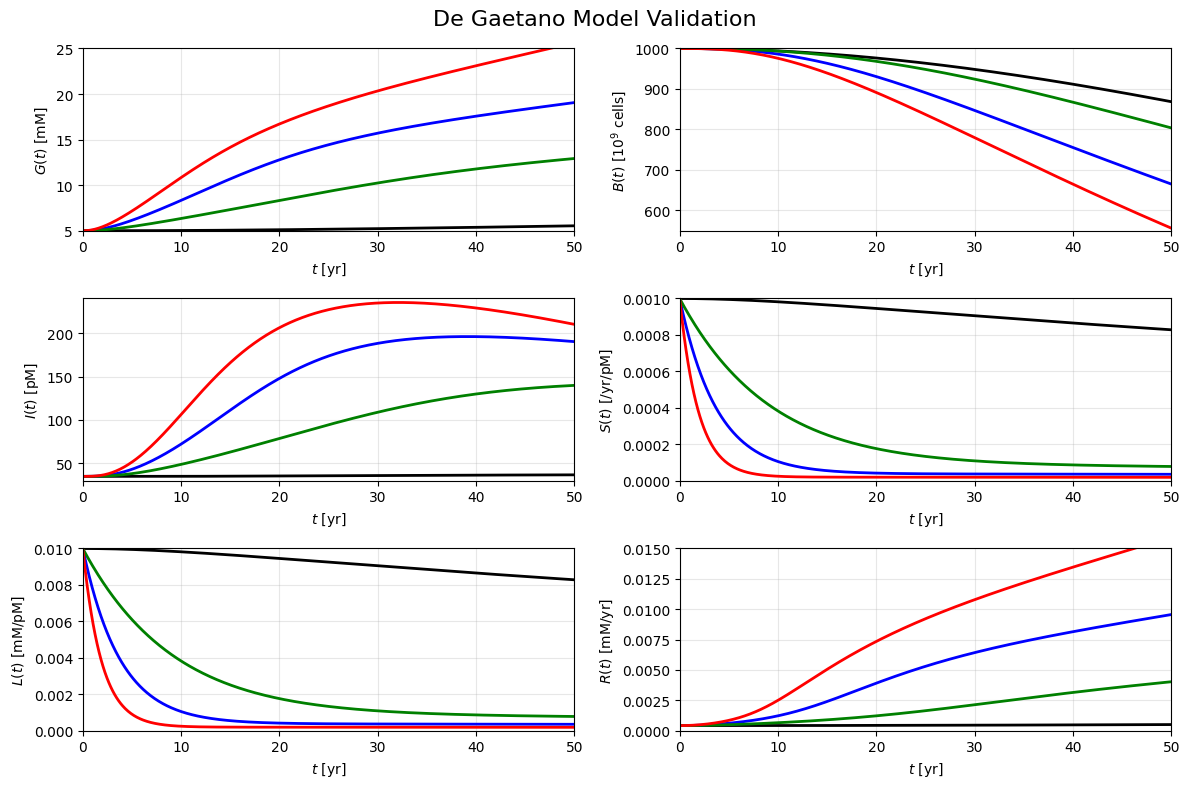

In [4]:
# =============================================================================
# PART 1: DE GAETANO PHYSIOLOGICAL MODEL
# =============================================================================

# Base parameters (Table 2)
params_base = {
    't0': 0, 'tend': 50, 't_delta': 0.1,
    'G0_N': 5.0, 'B_0': 1000.0, 'I0_N': 35.0,
    'S0_N': 0.001, 'L0_N': 0.01, 'R0': 0.000422144,
    'k_max_G': 1.00948, 'G_0': 5.0,
    'lambda_BA': 0.005, 'k_OB_G': 0.005, 'k_B': 25.0, 'B0_N': 1000.0,
    'k_OI': 0.5, 'gamma_IG': 2.0, 'G_I50': 20.0, 'k_max_I': 297.5, 'I_0': 35.0,
    'k_S': 0.0001, 'k_SY': 1e-09, 'k_OS': 0.1, 'k_OSF': 1e-05, 'k_OSA': 0.0005, 'S_0': 0.001,
    'k_L': 0.001, 'k_LY': 2e-09, 'k_OL': 0.1, 'k_OLF': 1e-05, 'k_OLA': 0.0005, 'L_0': 0.01,
    's_GR': 0.001, 'rho_GR': 0.5, 'G_R': 10.0, 'R0_N': 0.000422144,
    'F': 0.0, 'Y': 0.0, 'A0': 18.0
}


# Case parameters (Table 3)
params_cases = {}

for case in ['Black', 'Blue', 'Green', 'Red']:
    params_cases[case] = params_base.copy()

params_cases['Black'].update({
    'k_OB_G': 0.005, 'k_OS': 0.1, 'k_OL': 0.1,
    'k_B': 25.0, 'k_S': 0.0001, 'k_L': 0.001,
    'F': 0.0, 'k_OSF': 1e-05, 'k_OLF': 1e-5
})

params_cases['Blue'].update({
    'k_OB_G': 0.001, 'k_OS': 0.01, 'k_OL': 0.01,
    'k_B': 5.0, 'k_S': 1e-05, 'k_L': 0.0001,
    'F': 500.0, 'k_OSF': 0.0005, 'k_OLF': 0.0005
})

params_cases['Green'].update({
    'k_OB_G': 0.001, 'k_OS': 0.01, 'k_OL': 0.01,
    'k_B': 5.0, 'k_S': 1e-05, 'k_L': 0.0001,
    'F': 500.0, 'k_OSF': 0.0002, 'k_OLF': 0.0002
})

params_cases['Red'].update({
    'k_OB_G': 0.001, 'k_OS': 0.01, 'k_OL': 0.01,
    'k_B': 5.0, 'k_S': 1e-05, 'k_L': 0.0001,
    'F': 500.0, 'k_OSF': 0.001, 'k_OLF': 0.001
})

# Initial conditions (y0: [G, B, I, S, L, A]; B0=1000 Mc from Table 2)
A0=params_base['A0']
y0_base = jnp.array([params_base['G_0'], params_base['B_0'], params_base['I_0'], params_base['S_0'], params_base['L_0'],params_base['A0'] ])
print(y0_base)

# ODE RHS

def ode_rhs(t, y, params): #function ode_rhs that calculates how fast each body variable (like glucose or insulin) is changing at a specific moment t. It's the "rules" for how the system evolves, based on current states and settings.
    G, B, I, S, L, A = y #the array of state variables at time t
    F = params['F']
    Y = params['Y']

    # Eq 8: Renal R(G(t))
    discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2) # Calculates a helper number for the kidney function—it's part of smoothing out when kidneys start removing sugar (avoids sharp jumps).
    R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR'])) # Computes the kidney sugar removal rate (R) using a square root formula. It's like a gentle ramp-up: low when glucose is normal, higher when it's elevated.

    # Eq1: dG/dt: Describes glucose dynamics. It's max liver sugar production (slowed by insulin and liver sensitivity) minus sugar used by body tissues minus kidney removal.
    dGdt = params['k_max_G'] * (jnp.exp(-(L * I * G))) - (S * I * G) - R

    # Eq2: dB/dt : Describes beta cell mass dynamics. It's a base growth rate (that fades with age) minus damage from high sugar.
    dBdt = params['k_B'] * (jnp.exp(-params['lambda_BA'] * (A - A0))) - (params['k_OB_G'] * G * B)

    # Eq3: dI/dt (Hill function): Describes insulin dynamics
    hill = G**params['gamma_IG'] / ((params['G_I50']**params['gamma_IG']) + (G**params['gamma_IG'])) # shows how insulin secretion ramps up with higher glucose—starts slow, then accelerates, like a sensitivity switch.
    dIdt = -(params['k_OI'] * I) + ((B / params['B0_N']) * params['k_max_I'] * hill) # it's minus natural breakdown plus production from beta cells (scaled by their number and the glucose trigger)

    # Eq4: dS/dt : Peripheral insulin sensitivity: Base recovery minus natural fade plus exercise boost minus penalty from extra food minus age-related drop
    dSdt = params['k_S'] - (params['k_OS'] * S) + (params['k_SY'] * Y) - (params['k_OSF'] * F * S) - (params['k_OSA'] * (A - A0) * S)

    # Eq5: dL/dt: Liver insulin sensitivity dynamics: Base recovery minus fade plus exercise minus food penalty minus age drop.
    dLdt = params['k_L'] - (params['k_OL'] * L )+ (params['k_LY'] * Y )- (params['k_OLF'] * F * L) - (params['k_OLA'] * (A - A0) * L)

    # Eq6: dA/dt: Age: Age just increases steadily by 1 year per year
    dAdt = 1.0

    return jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt])

def ode_rhs_scan(y, t_span, opt_params, params, dt, y0): # Only introducing clipping and safe exponents to avoid Nans

    # Clip array of state variables at time t
    G = jnp.clip(y[0], 1e-6, 1e3)
    B = jnp.clip(y[1], 1e-6, 1e6)
    I = jnp.clip(y[2], 1e-6, 1e4)
    S = jnp.clip(y[3], 1e-6, 1e2)
    L = jnp.clip(y[4], 1e-6, 1e2)
    A = y[5]

    # Clip array of state variables at time t
    G0 = jnp.clip(y0[0], 1e-6, 1e3)
    B0 = jnp.clip(y0[1], 1e-6, 1e6)
    I0 = jnp.clip(y0[2], 1e-6, 1e4)
    S0 = jnp.clip(y0[3], 1e-6, 1e2)
    L0 = jnp.clip(y0[4], 1e-6, 1e2)
    A0 = y0[5]

    lambda_BA,k_OB_G,k_OI,k_OSF,k_OSA,k_OLF,k_OLA = opt_params

    F = params['F']
    Y = params['Y']

    # introduce safe exponents
    safe_exp_input_0 = jnp.clip(L0 * I0 * G0, -50, 50)
    safe_exp_input = -jnp.clip(L * I * G, -50, 50)

    # kidney function
    discriminant = (4 * params['rho_GR'] * G0) + ((G0 - params['G_R'] - params['rho_GR'])**2)
    R0 = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G0 - params['G_R'] - params['rho_GR']))

    discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2)
    R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR']))


    k_max_G = jnp.exp(safe_exp_input_0) * (S0 * I0 * G0 + R0)

    k_max_I = (k_OI * I0) / ((G0 ** params['gamma_IG']) / (params['G_I50'] ** params['gamma_IG'] + G0 ** params['gamma_IG']))

    k_B = k_OB_G * G0 * B0
    k_L = params['k_OL'] * L0 + k_OLF*F*L0
    k_S = params['k_OS'] * S0 + k_OSF*F*S0

    # Safe dynamics
    dGdt = k_max_G * jnp.exp(safe_exp_input) - (S * I * G) - R

    dBdt = k_B * (jnp.exp(-lambda_BA * (A - A0))) - (k_OB_G * G * B)

    hill = G**params['gamma_IG'] / ((params['G_I50']**params['gamma_IG']) + (G**params['gamma_IG']))
    dIdt = -(k_OI * I) + ((B / B0) * k_max_I * hill)

    dSdt = k_S - (params['k_OS'] * S) + (params['k_SY'] * Y) - (k_OSF * F * S) - (k_OSA * (A - A0) * S)

    dLdt = k_L - (params['k_OL'] * L )+ (params['k_LY'] * Y )- (k_OLF * F * L) - (k_OLA * (A - A0) * L)

    dAdt = 1.0

    next_state = y + dt*jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt])

    next_state = jnp.nan_to_num(next_state, nan=0.0, posinf=1e6, neginf=-1e6) # ensure simulation never breaks

    return next_state, next_state


#def ode_rhs_scan(y, t_span, opt_params , params, dt, y0):
    #G0, B0, I0, S0, L0, A0 = y0 #the array of state variables at time t
    #lambda_BA,k_OB_G,k_OI,k_OSF,k_OSA,k_OLF,k_OLA = opt_params

    #F = params['F'] #500.0
    #Y = params['Y']

    # Eq 8: Renal R(G(t))
    #discriminant = (4 * params['rho_GR'] * G0) + ((G0 - params['G_R'] - params['rho_GR'])**2) # Calculates a helper number for the kidney function—it's part of smoothing out when kidneys start removing sugar (avoids sharp jumps).
    #R0 = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G0 - params['G_R'] - params['rho_GR'])) # Computes the kidney sugar removal rate (R) using a square root formula. It's like a gentle ramp-up: low when glucose is normal, higher when it's elevated.

    #discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2) # Calculates a helper number for the kidney function—it's part of smoothing out when kidneys start removing sugar (avoids sharp jumps).
    #R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR'])) # Computes the kidney sugar removal rate (R) using a square root formula. It's like a gentle ramp-up: low when glucose is normal, higher when it's elevated.

    #k_max_G = (jnp.exp(L0 * I0 * G0)) * (S0 * I0 * G0 + R0)
    #k_max_I = (k_OI * I0) / ((G0 ** params['gamma_IG']) / (params['G_I50'] ** params['gamma_IG'] + G0 ** params['gamma_IG']))
    #k_B = k_OB_G * G0 * B0
    #k_L = params['k_OL'] * L0 + k_OLF*F*L0
    #k_S = params['k_OS'] * S0 + k_OSF*F*S0

    # k_max_G = (jnp.exp(params['L0_N'] * params['I0_N'] * params['G0_N'])) * (params['S0_N'] * params['I0_N'] * params['G0_N'] + params['R0_N'])
    # k_max_I = (params['k_OI'] * params['I0_N']) / ((params['G0_N'] ** params['gamma_IG']) / (params['G_I50'] ** params['gamma_IG'] + params['G0_N'] ** params['gamma_IG']))
    # k_B = params['k_OB_G'] *  params['G0_N'] *  params['B0_N']
    # k_L = params['k_OL'] *  params['L0_N']
    # k_S = params['k_OS'] *  params['S0_N']

    #k_max_G = params['k_max_G']
    #k_max_I = params['k_max_I']
    #k_B = params['k_B']
    #k_L = params['k_L']
    #k_S = params['k_S']

    # Eq1: dG/dt: Describes glucose dynamics. It's max liver sugar production (slowed by insulin and liver sensitivity) minus sugar used by body tissues minus kidney removal.
    #dGdt = k_max_G * (jnp.exp(-(L * I * G))) - (S * I * G) - R

    # Eq2: dB/dt : Describes beta cell mass dynamics. It's a base growth rate (that fades with age) minus damage from high sugar.
    #dBdt = k_B * (jnp.exp(-lambda_BA * (A - A0))) - (k_OB_G * G * B)

    # Eq3: dI/dt (Hill function): Describes insulin dynamics
    #hill = G**params['gamma_IG'] / ((params['G_I50']**params['gamma_IG']) + (G**params['gamma_IG'])) # shows how insulin secretion ramps up with higher glucose—starts slow, then accelerates, like a sensitivity switch.
    #dIdt = -(k_OI * I) + ((B / B0) * k_max_I * hill) # it's minus natural breakdown plus production from beta cells (scaled by their number and the glucose trigger)

    # Eq4: dS/dt : Peripheral insulin sensitivity: Base recovery minus natural fade plus exercise boost minus penalty from extra food minus age-related drop
    #dSdt = k_S - (params['k_OS'] * S) + (params['k_SY'] * Y) - (k_OSF * F * S) - (k_OSA * (A - A0) * S)

    # Eq5: dL/dt: Liver insulin sensitivity dynamics: Base recovery minus fade plus exercise minus food penalty minus age drop.
    #dLdt = k_L - (params['k_OL'] * L )+ (params['k_LY'] * Y )- (k_OLF * F * L) - (k_OLA * (A - A0) * L)

    # Eq6: dA/dt: Age: Age just increases steadily by 1 year per year
    #dAdt = 1.0
    #next_state = y + dt*jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt])
    #return next_state, next_state

# -----------------------------------------------------------------------------
# Euler solver
# -----------------------------------------------------------------------------
@jit
def solve_ode(params, t_span, y0):
    """Solve ODE with Diffrax"""
    def rhs(t, y, args): return ode_rhs(t, y, args) #A wrapper that calls the change-calculating function above.
    term = diffrax.ODETerm(rhs)
    solver = diffrax.Euler()
    sol = diffrax.diffeqsolve(term, solver, t0=t_span[0], t1=t_span[-1], dt0=0.1, y0=y0,args=params, saveat=diffrax.SaveAt(ts=t_span)) # Runs the solver: starts at time 0, goes to the end time, steps by 0.1 units, uses initial values y0, passes settings (params), and saves results at specific times in t_span.
    return sol.ys

t_span = jnp.linspace(0, 50, 1000)


print("Simulation completed")
#print("Solution shape:", sol.shape)



# PHYSIOLOGICAL MODEL VALIDATION PLOT

# R computation
def compute_R(G, params):
    discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2)
    R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR']))
    return R

# Time span


# Figure and colors
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
fig.suptitle("De Gaetano Model Validation", fontsize=16, y=0.98)

colors = {
    'Black': 'black',
    'Blue': 'blue',
    'Green': 'green',
    'Red': 'red'
}

for case, color in colors.items():

    # Get parameters
    params = params_cases[case]

    y0 = jnp.array([
        params['G_0'],
        params['B_0'],
        params['I_0'],
        params['S_0'],
        params['L_0'],
        params['A0']
    ])

    # Solve model
    start_t = time.time()
    sol = solve_ode(params, t_span, y0)
    print("Base:"+str(time.time()-start_t))

    sol = np.array(sol)

    # Create age axis
    age = np.linspace(0, 50, len(sol))

    # Plot states
    axes[0,0].plot(age, sol[:,0], color=color, linewidth=2, label=case)
    axes[0,1].plot(age, sol[:,1], color=color, linewidth=2, label=case)
    axes[1,0].plot(age, sol[:,2], color=color, linewidth=2, label=case)
    axes[1,1].plot(age, sol[:,3], color=color, linewidth=2, label=case)
    axes[2,0].plot(age, sol[:,4], color=color, linewidth=2, label=case)

     # Compute R from G
    R_values = compute_R(sol[:,0], params)
    axes[2,1].plot(age, R_values, color=color, linewidth=2.0)  # R(t)


# =============================================================================
# AXIS LABELS
# =============================================================================

axes[0,0].set_ylabel(r"$G(t)$ [mM]")
axes[0,0].set_xlabel(r"$t$ [yr]")
axes[0,0].set_xlim(0,50)
axes[0,0].set_ylim(5,25)

axes[0,1].set_ylabel(r"$B(t)$ [$10^9$ cells]")
axes[0,1].set_xlabel(r"$t$ [yr]")
axes[0,1].set_xlim(0,50)
axes[0,1].set_ylim(550,1000)

axes[1,0].set_ylabel(r"$I(t)$ [pM]")
axes[1,0].set_xlabel(r"$t$ [yr]")
axes[1,0].set_xlim(0,50)
axes[1,0].set_ylim(30,240)

axes[1,1].set_ylabel(r"$S(t)$ [/yr/pM]")
axes[1,1].set_xlabel(r"$t$ [yr]")
axes[1,1].set_xlim(0,50)
axes[1,1].set_ylim(0.0000,0.0010)

axes[2,0].set_ylabel(r"$L(t)$ [mM/pM]")
axes[2,0].set_xlabel(r"$t$ [yr]")
axes[2,0].set_xlim(0,50)
axes[2,0].set_ylim(0.000,0.010)

axes[2,1].set_ylabel(r"$R(t)$ [mM/yr]")
axes[2,1].set_xlabel(r"$t$ [yr]")
axes[2,1].set_xlim(0,50)
axes[2,1].set_ylim(0.000,0.015)


# Grid
for ax in axes.flat:
    ax.grid(True, alpha=0.3)

# Layout
plt.tight_layout()

# Save figure using global saver
save_figure(fig, "physiological_model_validation")

# Show plot
plt.show()

In [5]:
# =============================================================================
# UNIT CONVERSION
# =============================================================================

def convert_units_dataframe(df):
    """
    Convert NHANES units to model units
    """
    df = df.copy()

    # Glucose: mg/dL → mmol/L
    df["LBDGLUSI"] = df["LBDGLUSI"] / 18.0

    # Insulin: uU/mL → pM
    df["LBDINSI"] = df["LBDINSI"] * 6.0

    return df

# **Step 5: NHANES data Processing**

In [38]:
# =============================================================================
# LOAD NHANES DATA
# =============================================================================
cache_file = "nhanes_cached.pkl"
if os.path.exists(cache_file):

    print("Loading NHANES data from cache...")

    with open(cache_file, "rb") as f:
        data = pickle.load(f)

    print("Loaded cached dataset.")
    print("Rows:", len(data))

else:

    print("No cache found. Running full NHANES processing...")

    # Load demographic data
    demo, _ = pyreadstat.read_xport(
        demo_path,
        usecols=["SEQN", "WTMEC2YR", "RIDAGEYR", "RIAGENDR"]
    )

    # Load glucose / insulin data
    gluc, _ = pyreadstat.read_xport(gluc_path)

    # Load accelerometer data
    accel, _ = pyreadstat.read_xport(
        file_path,
        usecols=["SEQN", "PAXINTEN", "PAXSTAT", "PAXDAY"]
    )

    # Load dietary intake
    diet = pd.read_sas(DR1TOT_C)
    diet = diet[["SEQN", "DR1TKCAL"]]
    diet = diet[diet["DR1TKCAL"] > 0]


    # Merge datasets

    data = demo.copy()

    data = data.merge(gluc, on="SEQN", how="left")
    data = data.merge(diet, on="SEQN", how="left")

    # Process accelerometer data

    accel = accel[accel["PAXSTAT"] == 1]

    accel["intensity"] = pd.cut(
        accel["PAXINTEN"],
        bins=[-1, 99, 759, 2019, np.inf],
        labels=["sedentary", "light", "moderate", "vigorous"]
    )

    daily = (
        accel.groupby(["SEQN", "PAXDAY", "intensity"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    intensity_cols = ["sedentary", "light", "moderate", "vigorous"]

    for col in intensity_cols:
        if col not in daily.columns:
            daily[col] = 0

    daily["total_minutes"] = daily[intensity_cols].sum(axis=1)

    daily = daily[daily["total_minutes"] >= 600]

    person_activity = daily.groupby("SEQN")[intensity_cols + ["total_minutes"]].mean()

    person_activity["mvpa_minutes"] = (
        person_activity["moderate"] + person_activity["vigorous"]
    )

    data = data.merge(person_activity[["mvpa_minutes"]], on="SEQN", how="left")

    # Rename columns

    data = data.rename(
        columns={
            "RIDAGEYR": "age",
            "RIAGENDR": "gender",
            "WTMEC2YR": "weight",
            "DR1TKCAL": "calories",
            "LBDGLUSI": "glucose",
            "LBDINSI": "insulin"
        }
    )


    # Keep adults only

    data = data[data["age"] >= 18].copy()

    # ---------------------------------------------------------------------
    # Remove rows with missing required variables
    # ---------------------------------------------------------------------
    required_columns = ["age", "weight", "mvpa_minutes", "calories"]

    data = data.dropna(subset=required_columns)
    print("Datasets loaded successfully")

    # SAVE CACHE
    print("Saving processed dataset...")

    with open(cache_file, "wb") as f:
        pickle.dump(data, f)

    print("Cache saved:", cache_file)

Loading NHANES data from cache...
Loaded cached dataset.
Rows: 4511


In [39]:
# Cleaned data and summary

# Remove invalid weights, calories, mvpa_minutes
data = data[data["weight"] > 0]

data = data[(data["calories"] > 500) & (data["calories"] < 6000)]
data = data[(data["mvpa_minutes"] >= 0) & (data["mvpa_minutes"] < 600)]

print("Remaining individuals:", len(data))

print("Age range:", data["age"].min(), "-", data["age"].max())

print("Mean MVPA:", data["mvpa_minutes"].mean())

print("Mean calories:", data["calories"].mean())

data.head()


Remaining individuals: 4435
Age range: 18.0 - 85.0
Mean MVPA: 80.12950555645031
Mean calories: 2164.2822998872603


,SEQN,gender,age,weight,WTSAF2YR,LBXGLU,glucose,LBXCPSI,LBXIN,insulin,calories,mvpa_minutes
0,21005.0,1.0,19.0,5824.782465,14084.1,87.6,4.863,0.591,11.26,67.56,2984.0,102.428571
4,21009.0,1.0,55.0,97731.727244,NaN,NaN,NaN,NaN,NaN,NaN,5606.0,185.285714
5,21010.0,2.0,52.0,43286.576474,NaN,NaN,NaN,NaN,NaN,NaN,2171.0,134.142857
7,21012.0,1.0,63.0,12947.338142,NaN,NaN,NaN,NaN,NaN,NaN,2931.0,40.571429
10,21015.0,1.0,83.0,19994.159857,NaN,NaN,NaN,NaN,NaN,NaN,1394.0,17.142857


Saved: age_trends_20260408_104706.png


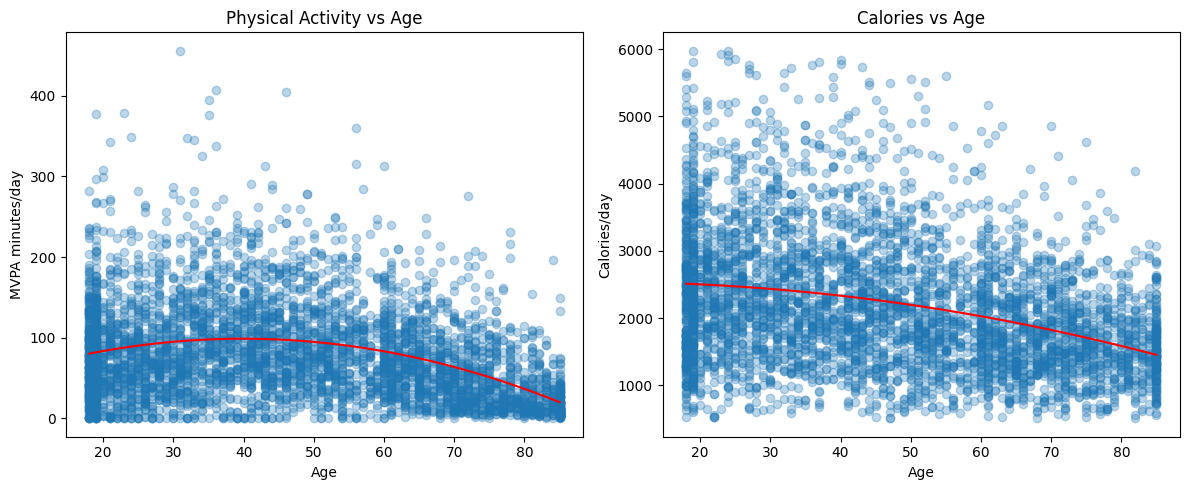

In [40]:
# =============================================================================
# AGE TRENDS: PHYSICAL ACTIVITY AND CALORIES VS AGE FOR THE WHOLE DATASET
# =============================================================================

fig, axes = plt.subplots(1,2, figsize=(12,5))

# Physical activity vs age
axes[0].scatter(data['age'], data['mvpa_minutes'], alpha=0.3)

z = np.polyfit(data['age'], data['mvpa_minutes'], 2)
p = np.poly1d(z)

x = np.linspace(data['age'].min(), data['age'].max(), 200)

axes[0].plot(x, p(x), color='red')

axes[0].set_title("Physical Activity vs Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("MVPA minutes/day")


# Calories vs age
axes[1].scatter(data['age'], data['calories'], alpha=0.3)

z = np.polyfit(data['age'], data['calories'], 2)
p = np.poly1d(z)

axes[1].plot(x, p(x), color='red')

axes[1].set_title("Calories vs Age")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Calories/day")


plt.tight_layout()

# Save figure
save_figure(fig, "age_trends")
plt.show()


In [41]:
# =============================================================================
# FIT AGE-DEPENDENT BEHAVIORAL MODELS
# =============================================================================

print("Fitting behavioral models...")

# Fit quadratic polynomial trends

mvpa_coeffs = np.polyfit(
    data["age"],
    np.log(data["mvpa_minutes"] + 1),
    2
) # Logtransform since mvpa is highly skewed, many small values few large values

calorie_coeffs = np.polyfit(
    data["age"],
    data["calories"],
    2
)

# Create polynomial models

mvpa_poly = np.poly1d(mvpa_coeffs)
calorie_poly = np.poly1d(calorie_coeffs)


# Compute residual variability

mvpa_residuals = np.log(data["mvpa_minutes"] + 1) - mvpa_poly(data["age"])

calorie_residuals = data["calories"] - calorie_poly(data["age"])


mvpa_sigma = np.std(mvpa_residuals)

calorie_sigma = np.std(calorie_residuals)


print("\nBehavior models fitted")

print("MVPA polynomial coefficients:", mvpa_coeffs)

print("Calories polynomial coefficients:", calorie_coeffs)

print("MVPA residual std:", mvpa_sigma)

print("Calories residual std:", calorie_sigma)


# Store results for later use

behavior_models = {
    "mvpa_poly": mvpa_poly,
    "calorie_poly": calorie_poly,
    "mvpa_sigma": mvpa_sigma,
    "calorie_sigma": calorie_sigma
}

Fitting behavioral models...

Behavior models fitted
MVPA polynomial coefficients: [-7.63065947e-04  6.32790010e-02  3.07418735e+00]
Calories polynomial coefficients: [-1.71072648e-01  1.83900632e+00  2.53219874e+03]
MVPA residual std: 0.9595291728840647
Calories residual std: 905.0051598197066


In [42]:
# =============================================================================
# BUILD INITIAL CONDITIONS FROM YOUNG NHANES INDIVIDUALS
# =============================================================================

n = 100   # number of individuals to sample

required_cols = [
    "age",
    "glucose",
    "insulin",
    "mvpa_minutes",
    "calories"
]

missing = [c for c in required_cols if c not in data.columns]

if missing:
    raise ValueError("Required NHANES columns missing: " + str(missing))


# Select young adults
young = data[(data["age"] >= 18) & (data["age"] <= 22)].copy()

if len(young) == 0:
    raise ValueError("No individuals aged 18–22 found")


# Remove rows with missing values
young = young.dropna(subset=required_cols)


if len(young) < n:
    raise ValueError(
        f"Requested {n} individuals but only {len(young)} have complete data"
    )


# Randomly sample individuals
sample = young.sample(n, random_state=42)


# Build initial state vectors
initials = []

for _, row in sample.iterrows():

    A0 = float(row["age"])
    G0= float(row["glucose"])
    I0= float(row["insulin"])
    MVPA0 = float(row["mvpa_minutes"])
    CAL0 = float(row["calories"])

    # Default physiological states
    #B0 = params_base['B_0']
    #S0 = params_base['S_0']
    #L0 = params_base['L_0']

    initials.append([
        G0,     # Glucose
        #B0,     # Beta cells
        I0,     # Insulin
        #S0,     # Peripheral sensitivity
        #L0,     # Liver sensitivity
        A0,     # Age
        MVPA0,  # Behavior (extra)
        CAL0    # Behavior (extra)
    ])


initials = np.array(initials)
initials_all=initials

print("\nYoung calibration cohort created")
print("Individuals:", len(initials))
print("Mean age:", np.mean(initials[:,2]))
print("Mean MVPA:", np.mean(initials[:,3]))
print("Mean calories:", np.mean(initials[:,4]))
print("Initials:",initials.shape)



Young calibration cohort created
Individuals: 100
Mean age: 19.13
Mean MVPA: 86.29857142857144
Mean calories: 2199.18
Initials: (100, 5)


In [43]:
# =============================================================================
# BUILD AGE-BINNED NHANES STATISTICS
# =============================================================================

data_filtered = data[(data["age"] >= 20) & (data["age"] <= 80)].copy()

bins = [10,20,30,40,50,60,70,80]

age_mid = np.array([15,25,35,45,55,65,75])


data_filtered["age_bin"] = pd.cut(
    data_filtered["age"],
    bins=bins,
    labels=age_mid
)


grouped = (
    data_filtered.groupby("age_bin", observed=True)[["glucose","insulin","mvpa_minutes","calories"]]
    .agg(["mean","std","count"])
    .dropna()
)


results = {
    "age_mid": age_mid,
    "G_mean": grouped["glucose"]["mean"].values,
    "G_sd": grouped["glucose"]["std"].values,
    "I_mean": grouped["insulin"]["mean"].values,
    "I_sd": grouped["insulin"]["std"].values,
    "mvpa_minutes_mean": grouped["mvpa_minutes"]["mean"].values,
    "mvpa_minutes_std": grouped["mvpa_minutes"]["std"].values,
    "calories_mean": grouped["calories"]["mean"].values,
    "calories_std": grouped["calories"]["std"].values,
}


print("Age-binned statistics built")

print("Age midpoints:", results["age_mid"])
print("Mean glucose:", results["G_mean"])
print("Mean insulin:", results["I_mean"])
print("Mean mvpa:", results["mvpa_minutes_mean"])
print("Mean calories:", results["calories_mean"])


# STORE TARGET TRAJECTORIES

age_midpoints = results["age_mid"]

G_mean_target = results["G_mean"]
G_sd_target = results["G_sd"]

I_mean_target = results["I_mean"]
I_sd_target = results["I_sd"]

mvpa_minutes_mean_target = results["mvpa_minutes_mean"]
mvpa_minutes_sd_target = results["mvpa_minutes_std"]

calories_mean_target = results["calories_mean"]
calories_sd_target = results["calories_std"]

print("Target trajectories saved.")

Age-binned statistics built
Age midpoints: [15 25 35 45 55 65 75]
Mean glucose: [4.98725    5.01777961 5.2985129  5.70500362 6.3021     6.54677346
 6.26537198]
Mean insulin: [98.44064516 63.98602649 78.98776699 60.91221818 69.5064     81.92932039
 66.62289855]
Mean mvpa: [ 82.3015873   84.58963585 102.77476868  99.57209097  88.39983735
  69.69059233  50.01472497]
Mean calories: [2392.74603175 2518.7605042  2477.97472354 2291.29829985 2025.59772296
 1858.01463415 1698.72536688]
Target trajectories saved.


In [44]:
# TRAIN / VALIDATION SPLIT
np.random.seed(42)

indices = np.arange(len(initials_all))
np.random.shuffle(indices)

split_index = int(0.7 * len(initials_all))

train_idx = indices[:split_index]
val_idx = indices[split_index:]

initials_train = initials_all[train_idx]
initials_val = initials_all[val_idx]

print("Training initials:", initials_train.shape)
print("Validation initials:", initials_val.shape)

Training initials: (70, 5)
Validation initials: (30, 5)


## **Fit a multivariate normal distribution to the (insulin, glucose) in the 18-22 age cohort**

In [13]:
# FIT MULTIVARIATE NORMAL (GLUCOSE, INSULIN)
glucose = young["glucose"].values
insulin = young["insulin"].values

# Log-transform
#log_glucose = np.log(np.clip(glucose, 1e-6, None))
#log_insulin = np.log(np.clip(insulin, 1e-6, None))

# Stack into (N,2)
data_pairs = np.column_stack((glucose, insulin)) #replaced because of negatives
#data_pairs = np.column_stack((log_glucose, log_insulin))

# Fit Gaussian in log-space
mean = np.mean(data_pairs, axis=0)
cov = np.cov(data_pairs.T)

print(data_pairs.shape)
print("Fitted mean:", mean)
print("Fitted covariance:", cov)

(333, 2)
Fitted mean: [ 5.0239009  72.57873874]
Fitted covariance: [[6.48531981e-01 1.58471433e+01]
 [1.58471433e+01 5.73631480e+03]]


Saved: Actual histogram of glucose insulin pairs_20260408_092323.png


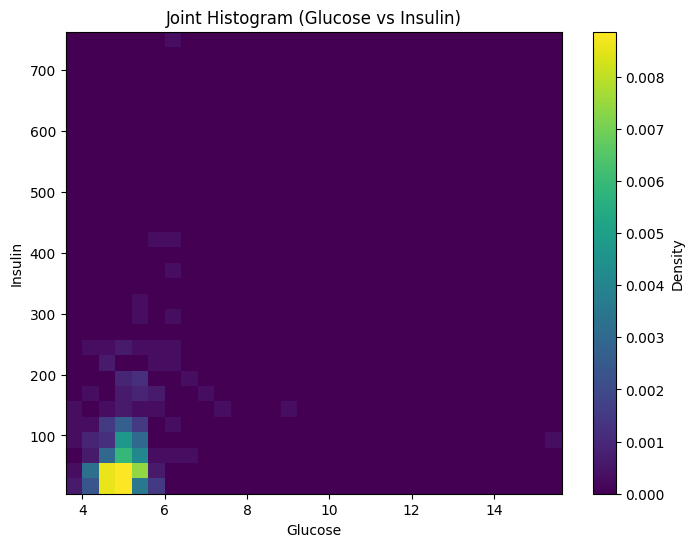

In [14]:
# ACTUAL HISTOGRAM OF (GLUCOSE, INSULIN) PAIRS
plt.figure(figsize=(8, 6))

plt.hist2d(glucose, insulin, bins=30, density=True)

plt.xlabel("Glucose")
plt.ylabel("Insulin")
plt.title("Joint Histogram (Glucose vs Insulin)")

plt.colorbar(label="Density")
fig = plt.gcf()
save_figure(fig, "Actual histogram of glucose insulin pairs")
plt.show()

Saved: Fitted distribution_20260408_105026.png


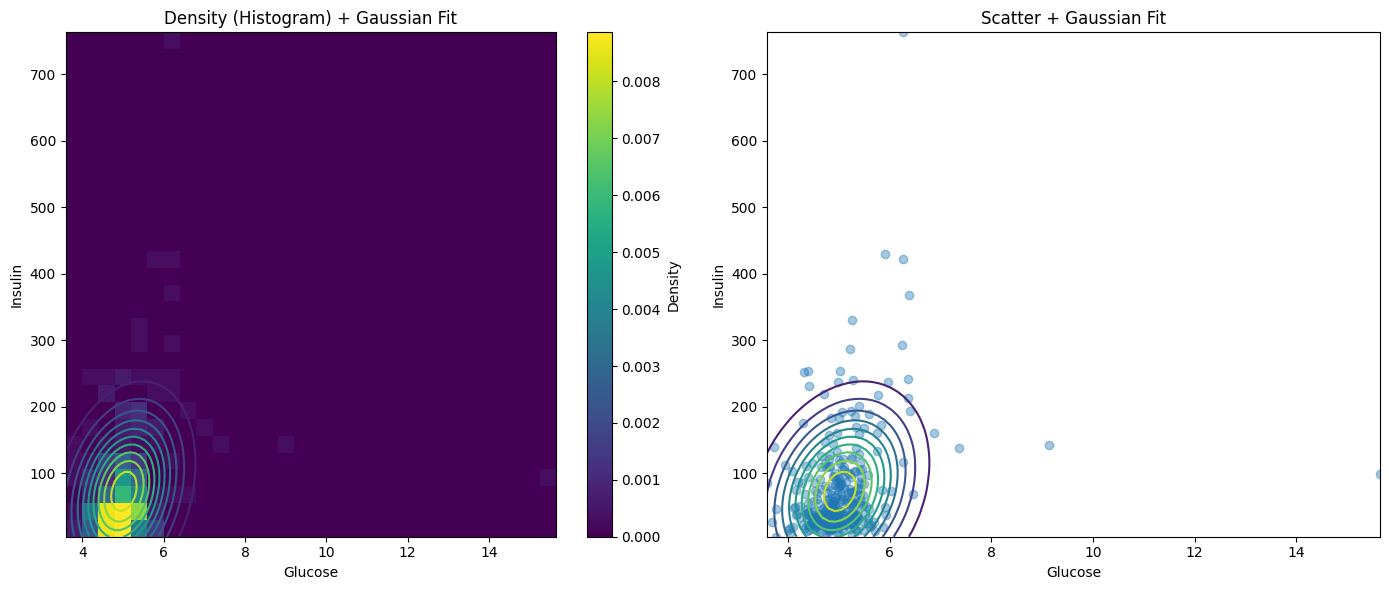

In [45]:
# Plots of fitted distribution

# Build grid

# Grid for visualization
x = np.linspace(glucose.min(), glucose.max(), 100)
y = np.linspace(insulin.min(), insulin.max(), 100)

X, Y = np.meshgrid(x, y)

# Combine grid
pos = np.dstack((X, Y))

# Evaluate gaussian

rv = multivariate_normal(mean, cov)

Z = rv.pdf(pos)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2D Histogram + Gaussian contours

hist = axes[0].hist2d(glucose, insulin, bins=30, density=True)

axes[0].contour(X, Y, Z, levels=10)

axes[0].set_xlabel("Glucose")
axes[0].set_ylabel("Insulin")
axes[0].set_title("Density (Histogram) + Gaussian Fit")

# Colorbar for histogram
fig.colorbar(hist[3], ax=axes[0], label="Density")

# Scatter + Gaussian contours

axes[1].scatter(glucose, insulin, alpha=0.4)
axes[1].contour(X, Y, Z, levels=10)

axes[1].set_xlabel("Glucose")
axes[1].set_ylabel("Insulin")
axes[1].set_title("Scatter + Gaussian Fit")

plt.tight_layout()
save_figure(fig, "Fitted distribution")
plt.show()

## **Defining Parameter Distributions over the model parameters**



  

In [16]:
# PARAM DISTRIBUTIONS
theta_keys = [
  "lambda_BA",
    "k_OB_G",
    "k_OI",
    "k_OSF",
    "k_OSA",
    "k_OLF",
    "k_OLA"
]

param_dist = {
    "lambda_BA": {"mu": 0.01, "sigma": 0.003},
    "k_OB_G":    {"mu": 0.01, "sigma": 0.003},
    "k_OI":      {"mu": 0.1,  "sigma": 0.02},
    "k_OSF":     {"mu": 0.01, "sigma": 0.003},
    "k_OSA":     {"mu": 0.01, "sigma": 0.003},
    "k_OLF":     {"mu": 0.01, "sigma": 0.003},
    "k_OLA":     {"mu": 0.01, "sigma": 0.003}
}

print("Initial guesses distribution")
print(param_dist)

# MULTIVARIATE INIT DISTRIBUTION
# Convert already computed mean/cov to jax arrays
mean_jax = jnp.array(mean)     # shape (2,)
cov_jax = jnp.array(cov)       # shape (2,2)


G_mu = mean_jax[0]
I_mu = mean_jax[1]

G_sigma = jnp.sqrt(cov_jax[0, 0])
I_sigma = jnp.sqrt(cov_jax[1, 1])

init_dist = {
    "glucose": {"mu": G_mu, "sigma": G_sigma},
    "insulin": {"mu": I_mu, "sigma": I_sigma}
}
print("Initial condition distributions:")
print(init_dist)

# SAMPLING FUNCTION
def sample_parameters(key, param_dist, init_mean, init_cov, N):

    # --- SPLIT MAIN KEYS ---
    key_params, key_init, key_age, key_behavior = random.split(key, 4)

    # --- SAMPLE AGE  ---
    ages = random.choice(
        key_age,
        jnp.array(young["age"]),
        shape=(N,)
    )

    # --- SAMPLE BEHAVIOR ---
    mvpa_mean = behavior_models["mvpa_poly"](ages)

    key_mvpa, key_cal = random.split(key_behavior)

    mvpa = jnp.exp(
        mvpa_mean +
        behavior_models["mvpa_sigma"] *
        random.normal(key_mvpa, shape=(N,))
    )

    calories = (
        behavior_models["calorie_poly"](ages) +
        behavior_models["calorie_sigma"] *
        random.normal(key_cal, shape=(N,))
    )

    # --- SPLIT KEYS FOR LOOP ---
    keys = random.split(key_params, N)

    samples = []
    matrix_samples = []

    for i in range(N):
        subkey = keys[i]
        sample = {}

        # Split key for params + multivariate
        subkeys = random.split(subkey, len(param_dist) + 1)

        vector_samples = []

        # --- PARAMS ---
        for j, (name, dist) in enumerate(param_dist.items()):
            val = random.normal(subkeys[j]) * dist["sigma"] + dist["mu"]
            sample[name] = val
            vector_samples.append(val)

        # --- MULTIVARIATE (G0, I0) ---
        gi_sample = random.multivariate_normal(
            subkeys[-1],
            mean=init_mean,
            cov=init_cov
        )

        sample["G0"] = gi_sample[0]
        sample["I0"] = jnp.clip(gi_sample[1], 1e-3, None)

        vector_samples.append(sample["G0"])
        vector_samples.append(sample["I0"])

        # --- ADD AGE + BEHAVIOR ---
        sample["age"] = ages[i]
        sample["mvpa"] = mvpa[i]
        sample["calories"] = calories[i]

        vector_samples.append(sample["age"])
        vector_samples.append(sample["mvpa"])
        vector_samples.append(sample["calories"])

        samples.append(sample)
        matrix_samples.append(jnp.array(vector_samples))

    return samples, jnp.stack(matrix_samples)

key = random.PRNGKey(0)

N = 10

samples, vectorized_samples = sample_parameters(
    key,
    param_dist,
    mean_jax,
    cov_jax,
    N
)

print(len(samples))
print(samples[0])
print(vectorized_samples.shape)

Initial guesses distribution
{'lambda_BA': {'mu': 0.01, 'sigma': 0.003}, 'k_OB_G': {'mu': 0.01, 'sigma': 0.003}, 'k_OI': {'mu': 0.1, 'sigma': 0.02}, 'k_OSF': {'mu': 0.01, 'sigma': 0.003}, 'k_OSA': {'mu': 0.01, 'sigma': 0.003}, 'k_OLF': {'mu': 0.01, 'sigma': 0.003}, 'k_OLA': {'mu': 0.01, 'sigma': 0.003}}
Initial condition distributions:
{'glucose': {'mu': Array(5.023901, dtype=float32), 'sigma': Array(0.80531484, dtype=float32)}, 'insulin': {'mu': Array(72.578735, dtype=float32), 'sigma': Array(75.738464, dtype=float32)}}
10
{'lambda_BA': Array(0.00561126, dtype=float32), 'k_OB_G': Array(0.0058367, dtype=float32), 'k_OI': Array(0.07497339, dtype=float32), 'k_OSF': Array(0.008972, dtype=float32), 'k_OSA': Array(0.01296439, dtype=float32), 'k_OLF': Array(0.00967875, dtype=float32), 'k_OLA': Array(0.01586777, dtype=float32), 'G0': Array(5.315275, dtype=float32), 'I0': Array(0.001, dtype=float32), 'age': Array(19., dtype=float32), 'mvpa': Array(274.45258, dtype=float32), 'calories': Array(3

##**Reparametrization Trick for Model Parameters**

In [17]:
#print(samples[0])
theta_keys = [
    "lambda_BA", "k_OB_G", "k_OI",
    "k_OSF", "k_OSA", "k_OLF", "k_OLA"
]

# Initial guesses
# param_dist = {
#     "lambda_BA": {"mu": params_base["lambda_BA"], "sigma": 0.003},
#     "k_OB_G":    {"mu": params_base["k_OB_G"], "sigma": 0.003},
#     "k_OI":      {"mu": params_base["k_OI"],  "sigma": 0.02},
#     "k_OSF":     {"mu": params_base["k_OSF"], "sigma": 0.003},
#     "k_OSA":     {"mu": params_base["k_OSA"], "sigma": 0.003},
#     "k_OLF":     {"mu": params_base["k_OLF"], "sigma": 0.003},
#     "k_OLA":     {"mu": params_base["k_OLA"], "sigma": 0.003}
# }
param_dist = {
    "lambda_BA": {"mu": 0.01, "sigma": 0.003},
    "k_OB_G":    {"mu": 0.01, "sigma": 0.003},
    "k_OI":      {"mu": 0.1,  "sigma": 0.02},
    "k_OSF":     {"mu": 0.01, "sigma": 0.003},
    "k_OSA":     {"mu": 0.01, "sigma": 0.003},
    "k_OLF":     {"mu": 0.01, "sigma": 0.003},
    "k_OLA":     {"mu": 0.01, "sigma": 0.003}
}

mus = jnp.log(jnp.array([param_dist[k]["mu"] for k in theta_keys]))
sigmas = jnp.log(jnp.array([param_dist[k]["sigma"] for k in theta_keys]))

def reparameterized_sample(mus, sigmas, eps): # sample from log_normal distribution making sampling differentiable
    scale = jax.nn.softplus(sigmas) + 1e-6
    return jnp.exp(mus + scale * eps)

def build_params(param_sample):# take a sampled parameter vector and convert to a dictionary for the solver
    return {
        **params_base,
        "lambda_BA": param_sample[0],
        "k_OB_G":    param_sample[1],
        "k_OI":      param_sample[2],
        "k_OSF":     param_sample[3],
        "k_OSA":     param_sample[4],
        "k_OLF":     param_sample[5],
        "k_OLA":     param_sample[6],
    }
key = jax.random.PRNGKey(0) #jax random seed

N_samples = 20  # keep small initially

# noise for reparameterization
key, subkey = jax.random.split(key)
eps = jax.random.normal(subkey, shape=(N_samples, 7))

param_samples = vmap(reparameterized_sample, in_axes=(None, None, 0))(mus, sigmas, eps)
print(param_samples.shape)

(20, 7)


In [18]:
# SIMULATE ONE SAMPLE
def simulate_one_sample(sample, params_base, t_span):

  # Copy base params
  params = params_base.copy()

  # Update with sampled theta parameters
  for key in theta_keys:
      params[key] = sample[key]

  # Add F and Y
  params['F'] = sample["calories"]   # food intake
  params['Y'] = sample["mvpa"]       # physical activity

  # Initial conditions
  G0 = jnp.clip(sample["G0"], 2.0, 15.0)
  I0 = jnp.clip(sample["I0"], 1e-3, 300.0)
  B0 = params['B_0']
  S0 = params['S_0']
  L0 = params['L_0']

  y0 = jnp.array([
      G0,   # G
      B0,   # B
      I0,   # I
      S0,   # S
      L0,   # L
      sample["age"]   # use sampled age
  ])

  # Solve ODE
  ys = solve_ode(params, t_span, y0)
  #if jnp.isnan(ys).any() or jnp.isinf(ys).any():
      #print("Bad sample:", sample)

  # Extract glucose trajectory (index 0)
  G_traj = ys[:, 0]

  return ys

# SIMULATE ALL SAMPLES
t_span = jnp.linspace(18, 80, 1000)

N_samples = 10

# BUILD INITIAL STATES
G0 = jnp.clip(vectorized_samples[:, -5], 2.0, 15.0)
I0 = jnp.clip(vectorized_samples[:, -4], 1e-3, 300.0)
A0_samples = vectorized_samples[:, -3]
mvpa_samples = jnp.clip(vectorized_samples[:, -2], 0.0, 1e4)
calorie_samples = jnp.clip(vectorized_samples[:, -1], 0.0, 5000.0)

init_samples = jnp.column_stack([
    G0,
    jnp.full(N_samples, params_base['B_0']),
    I0,
    jnp.full(N_samples, params_base['S_0']),
    jnp.full(N_samples, params_base['L_0']),
    A0_samples
])
#print(init_samples)

# SAMPLE PARAMETERS
key, subkey = jax.random.split(key)
eps = jax.random.normal(subkey, shape=(N_samples, 7))

param_samples = vmap(reparameterized_sample,in_axes=(None, None, 0))(mus, sigmas, eps)

# Safety clip
param_samples = jnp.clip(param_samples, 1e-6, None)

# TIME STEP
dt = t_span[1] - t_span[0]

def build_params(param_ind, mvpa, calories):
    params = dict(params_base)

    # ONLY inputs here
    params["F"] = calories
    params["Y"] = mvpa

    return params

def simulate_scan(param_ind, init_ind, mvpa, calories):

    params = build_params(param_ind, mvpa, calories)

    def step(y, t):
        y_next, _ = ode_rhs_scan(y, t, param_ind, params, dt, init_ind)

        #jax.debug.print("NaN: {}", jnp.isnan(y_next).any())

        return y_next, y_next

    _, ys = jax.lax.scan(step, init_ind, t_span)

    return ys

# VMAP OVER INDIVIDUALS

states = jax.vmap(simulate_scan)(
    param_samples,
    init_samples,
    mvpa_samples,
    calorie_samples
)

print("States shape:", states.shape)

# EXTRACT TRAJECTORIES

all_G = states[:, :, 0]
all_I = states[:, :, 2]

print("G shape:", all_G.shape)
print("I shape:", all_I.shape)

# NaN CHECK

for i, G_traj in enumerate(all_G):
    if jnp.isnan(G_traj).any():
        print(f"NaN in trajectory {i}")

States shape: (10, 1000, 6)
G shape: (10, 1000)
I shape: (10, 1000)


In [19]:
# Check just one step
y_test = init_samples[0]
param_test = param_samples[0]

params = build_params(param_test, mvpa_samples[0], calorie_samples[0])

y_next, _ = ode_rhs_scan(y_test, t_span[0], param_test, params, dt, y_test)

print(y_next)
#print(dIdt)
print(y_test[2]) # check insulin

[5.3152752e+00 1.0000000e+03 1.0000000e-03 1.0000172e-03 1.0000033e-02
 1.9062061e+01]
0.001


In [20]:
def reparameterized_sample(mus, sigmas, eps): # sample from log_normal distribution making sampling differentiable
    scale = jax.nn.softplus(sigmas) + 1e-6
    return jnp.exp(mus + scale * eps)

#def calc_lppd(measurements, mask, sims): # Computes log predictive probability density
    #diffs = sims-measurements[:,None]
    #sigma = 0.5
    #log_coef = -jnp.log(jnp.sqrt(2 * jnp.pi) * sigma)
    #log_probs = (log_coef - 0.5 * (diffs / sigma)**2)
    #print(log_probs.shape)
    #return jax.nn.logmeanexp(log_probs,axis=1,where=mask[:,None])

def calc_lppd(measurements, mask, sims, sigma):
    diffs = sims - measurements[:, None]
    # Clamp differences
    diffs = jnp.clip(diffs, -20.0, 20.0)

    log_probs = -0.5 * (diffs / sigma)**2 - jnp.log(jnp.sqrt(2*jnp.pi)*sigma)

    return jax.nn.logmeanexp(log_probs, axis=1, where=mask[:, None])

# Time safe indexing
def time_to_index(t, dt):
    return ((t - 18.0) / dt).astype(int)


def scan_loss_fn(optax_params,glucose, insulin, mask,eps, eps2,mvpa_data, calorie_data): #main loss function; training objective
    mus = optax_params["mus"] # extract parameters; learned parameters optimized by optax
    sigmas = optax_params["sigmas"] #extract parameters

    dt=0.01
    t_span = jnp.linspace(18, 80, int((80-18)/dt+1))
    #print(A0)
    #print(t_span)
    #print(t_span[1]-t_span[0])

    # Initial state sampling
    G0 = jnp.clip(
        jax.nn.softplus(init_dist["glucose"]["mu"] + init_dist["glucose"]["sigma"] * eps2[:, 0]),
        2.0, 15.0
    )

    I0 = jnp.clip(
        jax.nn.softplus(init_dist["insulin"]["mu"] + init_dist["insulin"]["sigma"] * eps2[:, 1]),
        0.0, 300.0
    )

    N = G0.shape[0]

    init_samples = jnp.column_stack([
        G0,
        jnp.full(N, params_base['B_0']),
        I0,
        jnp.full(N, params_base['S_0']),
        jnp.full(N, params_base['L_0']),
        jnp.full(N, A0)
    ])

    # parameter samples
    param_samples = jax.vmap(reparameterized_sample, in_axes=(None, None, 0))(mus, sigmas, eps)

    # Clip params
    param_samples = jnp.clip(param_samples, 1e-6, None)

    # Scan with inputs
    def simulate_one(param_ind, init_ind, mvpa, calories):

        params = build_params(param_ind, mvpa, calories)

        def step(y, t):
            y_next, _ = ode_rhs_scan(y, t, param_ind, params, dt, init_ind)
            return y_next, y_next

        _, ys = jax.lax.scan(step, init_ind, t_span)
        return ys

    states = jax.vmap(simulate_one)(param_samples,init_samples,mvpa_data,calorie_data)

    # Numerical safety
    states = jnp.nan_to_num(states, nan=0.0, posinf=1e6, neginf=-1e6)

    # Midpoints
    ages = jnp.array(age_list)  # e.g. [15,25,35,...]

    # convert age → index
    midpoints = ((ages - 18) / (80 - 18) * (states.shape[1] - 1)).astype(int)
    midpoints = jnp.clip(midpoints, 0, states.shape[1] - 1)

    # likelihood
    # ---- glucose likelihood ----
    logexps_glucose = jax.vmap(
        lambda glucose_bin, mask_bin, midpoint:
            calc_lppd(glucose_bin, mask_bin, states[:, midpoint, 0][None, :], sigma=1.0),
        (0, 0, 0)
    )(glucose, mask, midpoints)

    # ---- insulin likelihood ----
    logexps_insulin = jax.vmap(
        lambda insulin_bin, mask_bin, midpoint:
            calc_lppd(insulin_bin, mask_bin, states[:, midpoint, 2][None, :], sigma=20.0),
        (0, 0, 0)
    )(insulin, mask, midpoints)


    # combine
    alpha = 1.0
    beta = 0.5


    logexps_bins = jnp.nanmean(alpha * logexps_glucose + beta * logexps_insulin, axis=1)

    return -jnp.mean(logexps_bins)

    print(logexps.shape)


def debug_simulation(optax_params, mvpa_data, calorie_data, eps, eps2):

    mus = optax_params["mus"]
    sigmas = optax_params["sigmas"]

    dt = 0.01
    t_span = jnp.linspace(18, 80, int((80-18)/dt+1))

    # sample initial states
    G0 = jnp.clip(
        jax.nn.softplus(init_dist["glucose"]["mu"] + init_dist["glucose"]["sigma"] * eps2[:, 0]),
        2.0, 15.0
    )

    I0 = jnp.clip(
        jax.nn.softplus(init_dist["insulin"]["mu"] + init_dist["insulin"]["sigma"] * eps2[:, 1]),
        0.0, 300.0
    )

    N = G0.shape[0]

    init_samples = jnp.column_stack([
        G0,
        jnp.full(N, params_base['B_0']),
        I0,
        jnp.full(N, params_base['S_0']),
        jnp.full(N, params_base['L_0']),
        jnp.full(N, A0)
    ])

    param_samples = jax.vmap(reparameterized_sample, in_axes=(None, None, 0))(mus, sigmas, eps)
    param_samples = jnp.clip(param_samples, 1e-6, None)

    def simulate_one(param_ind, init_ind, mvpa, calories):
        params = build_params(param_ind, mvpa, calories)

        def step(y, t):
            y_next, _ = ode_rhs_scan(y, t, param_ind, params, dt, init_ind)
            return y_next, y_next

        _, ys = jax.lax.scan(step, init_ind, t_span)
        return ys

    states = jax.vmap(simulate_one)(param_samples, init_samples, mvpa_data, calorie_data)

    return t_span, states

In [30]:
# Set age-list
age_list = list(age_midpoints)

# Build bins
real_bins = {}
insulin_bins = {}

for age in age_list:
    subset = data_filtered[data_filtered["age_bin"] == age]
    subset_clean = subset[["glucose", "insulin"]].dropna()

    g_vals = subset_clean["glucose"].values
    i_vals = subset_clean["insulin"].values

    if len(g_vals) == 0:
        print(f"⚠️ Empty glucose bin at age {age}")

    if len(i_vals) == 0:
        print(f"⚠️ Empty insulin bin at age {age}")

    real_bins[age] = g_vals
    insulin_bins[age] = i_vals

age_list = [age for age in age_list if len(real_bins[age]) > 0]


# Get max_K
max_K = max(len(real_bins[age]) for age in age_list)


# Build arrays and masks
real_array = []
insulin_array = []
mask_array = []

for age in age_list:

    g_vals = real_bins[age]
    i_vals = insulin_bins[age]

    K = len(g_vals)

    # Pad both with same length
    g_padded = np.pad(g_vals, (0, max_K - K), constant_values=0.0)
    i_padded = np.pad(i_vals, (0, max_K - K), constant_values=0.0)

    # Single shared mask
    mask = np.concatenate([np.ones(K), np.zeros(max_K - K)])

    real_array.append(g_padded)
    insulin_array.append(i_padded)
    mask_array.append(mask)


# convert to JAX
real_array = jnp.array(real_array)
insulin_array = jnp.array(insulin_array)
mask_array = jnp.array(mask_array, dtype=bool)


# sanity check
print("real_array shape:", real_array.shape)
print("insulin_array shape:", insulin_array.shape)

for age in age_list[:5]:  # check first few
    print(f"Age {age}: K = {len(real_bins[age])}")


mus = jnp.log(jnp.array([param_dist[k]["mu"] for k in theta_keys]))
sigmas = jnp.log(jnp.array([param_dist[k]["sigma"] for k in theta_keys]))

#print(age_list)

print(real_array[0])

key, subkey1, subkey2 = jax.random.split(key, 3)
eps  = jax.random.normal(subkey1, shape=(N_samples, 7))
eps2 = jax.random.normal(subkey2, shape=(N_samples, 2))

optax_params = {"mus":mus,"sigmas":sigmas}

mvpa_data = jnp.clip(vectorized_samples[:, -2], 0.0, 1e4)
calorie_data = jnp.clip(vectorized_samples[:, -1], 0.0, 5000.0)

scan_loss_fn(optax_params,real_array,mask_array,insulin_array,eps,eps2,mvpa_data,calorie_data)

optimizer = optax.adam(1e-3)
opt_state = optimizer.init(optax_params)

@jax.jit
def train_step(params, opt_state, real_array, mask_array,insulin_array,mvpa_data, calorie_data, key):
    N_samples = 10  # keep small initially
    # noise for reparameterization
    key, subkey1, subkey2 = jax.random.split(key, 3)
    eps = jax.random.normal(subkey1, shape=(N_samples, 7))
    eps2 = jax.random.normal(subkey2, shape=(N_samples, 2))

    loss, grads = jax.value_and_grad(scan_loss_fn, argnums=0)(params,real_array,mask_array,insulin_array,eps,eps2,mvpa_data,calorie_data)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss, key

pbar = tqdm(range(100))
for step in pbar:
#for i in tqdm(range(100)):
    key, subkey = jax.random.split(key)
    optax_params, opt_state, loss, key = train_step(
    optax_params,
    opt_state,
    real_array,
    mask_array,
    insulin_array,
    mvpa_data,
    calorie_data,
    subkey
)
    pbar.set_postfix({"loss": float(loss)})
    #print(loss)
    #print(optax_params)

print("params:", optax_params)
print("loss:", loss)

real_array shape: (7, 308)
insulin_array shape: (7, 308)
Age 15: K = 31
Age 25: K = 302
Age 35: K = 308
Age 45: K = 275
Age 55: K = 249
[5.457 4.979 5.335 3.591 4.852 4.618 4.319 4.519 4.607 5.124 6.256 4.424
 4.746 5.013 5.307 5.063 5.029 5.834 4.291 4.352 5.484 4.746 4.474 4.846
 5.057 6.883 5.718 4.785 4.835 4.718 5.29  0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.   

100%|██████████| 100/100 [00:15<00:00,  6.42it/s, loss=10.6]

params: {'mus': Array([-4.507642 , -4.508958 , -2.2052624, -4.6967015, -4.513681 ,
       -4.694969 , -4.515434 ], dtype=float32), 'sigmas': Array([-5.7975063, -5.8049474, -3.9041588, -5.8120193, -5.8090467,
       -5.8014336, -5.8221493], dtype=float32)}
loss: 10.596233


In [22]:
print(optax_params)
#optax_params["mus"] = 0.001*jnp.ones_like(optax_params["mus"])
for i in range(7,):
    print(np.mean(real_array[i][mask_array[i]]))
key, subkey = jax.random.split(key)
eps = jax.random.normal(subkey, shape=(N_samples, 7))
eps2 = jax.random.normal(subkey, shape=(N_samples, 2))
scan_loss_fn(optax_params,real_array,mask_array,insulin_array,eps,eps2,mvpa_data,calorie_data)

{'mus': Array([-4.505921 , -4.506876 , -2.2033029, -4.7023487, -4.508035 ,
       -4.700645 , -4.509734 ], dtype=float32), 'sigmas': Array([-5.808064 , -5.801181 , -3.915259 , -5.8138824, -5.811911 ,
       -5.811329 , -5.779292 ], dtype=float32)}
4.9855485
5.022298
5.300318
5.7097826
6.3046703
6.5450516
6.2653713


Array(10.517967, dtype=float32)

In [23]:
def plot_glucose_insulin(states, t_span, age_list, real_bins, insulin_bins):

    # convert from JAX → NumPy
    states_np = np.array(states)
    t_span_np = np.array(t_span)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # =========================
    # GLUCOSE
    # =========================
    ax = axes[0]

    for i in range(states_np.shape[0]):
        ax.plot(t_span_np, states_np[i,:,0], alpha=0.2)

    mean_G = states_np[:,:,0].mean(axis=0)
    ax.plot(t_span_np, mean_G, linewidth=2)

    for age in age_list:
        vals = real_bins[age]
        ax.scatter([age]*len(vals), vals, color='red', alpha=0.2, s=10)

    ax.set_title("Glucose: Model vs Data")
    ax.set_xlabel("Age")
    ax.set_ylabel("Glucose")
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 10])


    # =========================
    # INSULIN
    # =========================
    ax = axes[1]

    for i in range(states_np.shape[0]):
        ax.plot(t_span_np, states_np[i,:,2], alpha=0.2)

    mean_I = states_np[:,:,2].mean(axis=0)
    ax.plot(t_span_np, mean_I, linewidth=2)

    for age in age_list:
        vals = insulin_bins[age]
        ax.scatter([age]*len(vals), vals, color='red', alpha=0.2, s=10)

    ax.set_title("Insulin Dynamics (Model)")
    ax.set_xlabel("Age")
    ax.set_ylabel("Insulin")
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 500])

    plt.suptitle("Model Behavior vs Real Data", fontsize=16)
    plt.tight_layout()
    save_figure(fig, "Model Behavior vs Real Data")
    plt.show()

def plot_all_states(states, t_span):

    states_np = np.array(states)
    t_span_np = np.array(t_span)

    labels = ["Glucose (G)", "Beta cells (B)", "Insulin (I)", "Sensitivity (S)", "Liver (L)"]

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i in range(5):
        ax = axes[i]

        for j in range(states_np.shape[0]):
            ax.plot(t_span_np, states_np[j,:,i], alpha=0.2)

        mean_traj = states_np[:,:,i].mean(axis=0)
        ax.plot(t_span_np, mean_traj, linewidth=2)

        ax.set_title(labels[i])
        ax.set_xlabel("Age")
        ax.set_ylabel("Value")
        ax.grid(True, alpha=0.3)

    fig.delaxes(axes[5])

    plt.suptitle("New Simulated Physiological Trajectories", fontsize=16)
    plt.tight_layout()
    save_figure(fig,"New Simulated Physiological Trajectories")
    plt.show()

Saved: Model Behavior vs Real Data_20260408_095700.png


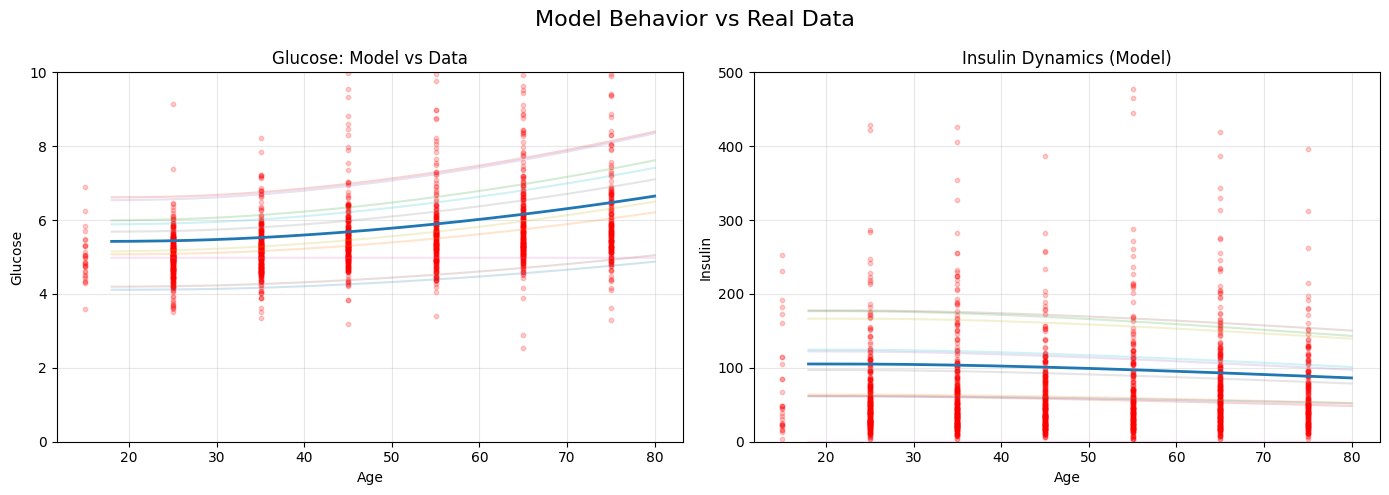

Saved: New Simulated Physiological Trajectories_20260408_095705.png


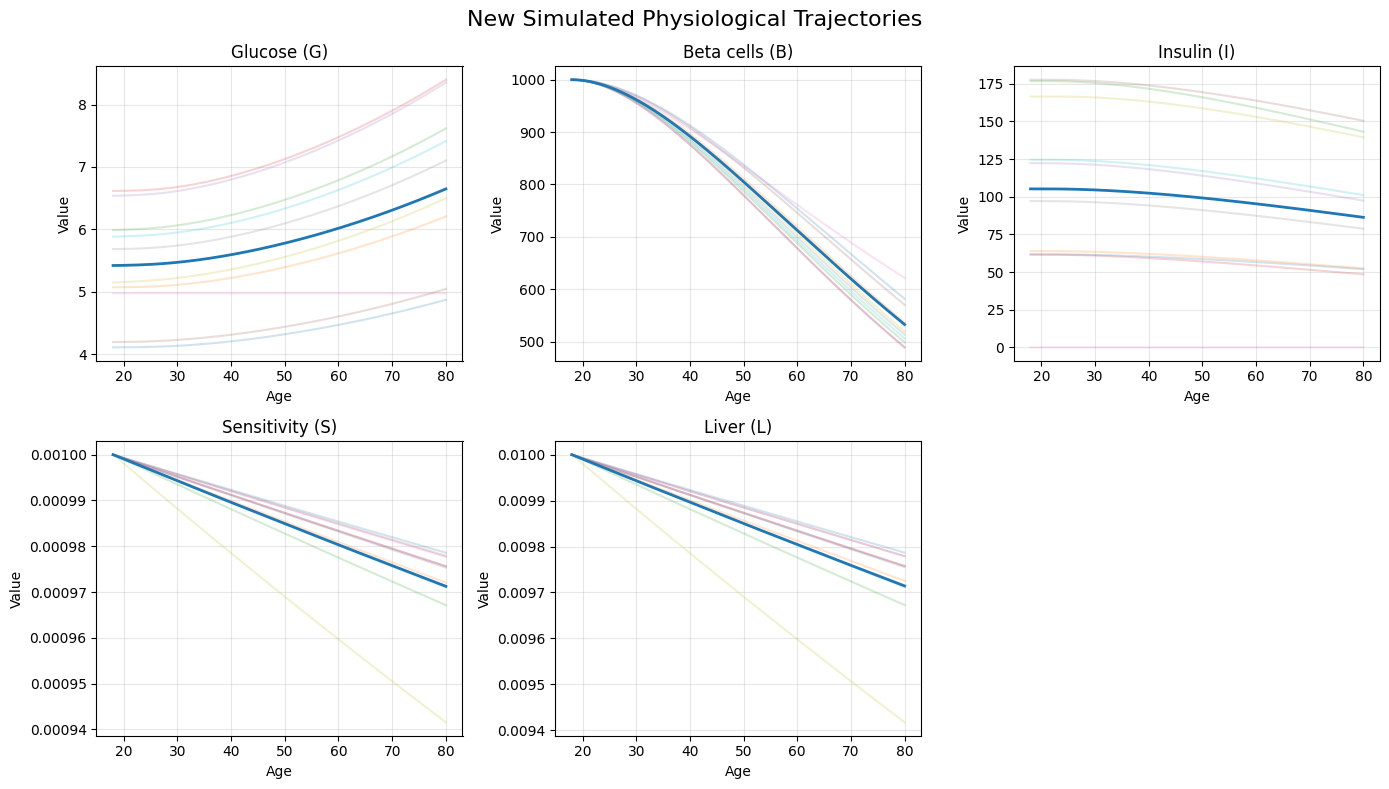

In [29]:
t_span, states = debug_simulation(optax_params, mvpa_data, calorie_data, eps, eps2)

plot_glucose_insulin(states, t_span, age_list, real_bins, insulin_bins)
plot_all_states(states, t_span)

In [25]:
# DEFINE DISTRIBUTIONS FOR THE 7 PARAMETERS
#theta_keys = [
    #"lambda_BA",
    #"k_OB_G",
    #"k_OI",
    #"k_OSF",
    #"k_OSA",
    #"k_OLF",
    #"k_OLA"
#]

# Initial guesses
#param_dist = {
    #"lambda_BA": {"mu": 0.01, "sigma": 0.003},
    #"k_OB_G":    {"mu": 0.01, "sigma": 0.003},
    #"k_OI":      {"mu": 0.1,  "sigma": 0.02},
    #"k_OSF":     {"mu": 0.01, "sigma": 0.003},
    #"k_OSA":     {"mu": 0.01, "sigma": 0.003},
    #"k_OLF":     {"mu": 0.01, "sigma": 0.003},
    #"k_OLA":     {"mu": 0.01, "sigma": 0.003}
#}

#mus = jnp.array([param_dist[k]["mu"] for k in theta_keys])
#sigmas = jnp.array([param_dist[k]["sigma"] for k in theta_keys])

#print("Initial guesses distribution")
#print(param_dist)

#key = jax.random.PRNGKey(0) #jax random seed


# Generate N random

#def sample_parameters(mus, sigmas, mean, cov, N, key):

    #key_params, key_init, key_age, key_behavior = jax.random.split(key, 4)

    # SAMPLE PARAMETERS (log-normal to ensure positivity)
    #eps = jax.random.normal(key_params, shape=(N, mus.shape[0]))
    #log_params = jnp.log(mus) + sigmas * eps
    #param_samples = jnp.exp(log_params)

    # SAMPLE GLUCOSE & INSULIN
    #init_samples_GI  = jax.random.multivariate_normal(
        #key_init, mean, cov, shape=(N,)
    #)
    #init_samples_GI = jnp.clip(init_samples_GI, a_min=1e-6) # clip any negatives

    # SAMPLE AGE
    #ages = jax.random.choice(
        #key_age,
        #jnp.array(young["age"]),
        #shape=(N,)
    #)

    # SAMPLE BEHAVIOR (from fitted models)
    #mvpa_mean = behavior_models["mvpa_poly"](ages)

    #key_mvpa, key_cal = jax.random.split(key_behavior)

    #mvpa = jnp.exp(
        #mvpa_mean +
        #behavior_models["mvpa_sigma"] *
        #jax.random.normal(key_mvpa, shape=(N,))
    #)

    #calories = (
        #behavior_models["calorie_poly"](ages) +
        #behavior_models["calorie_sigma"] *
        #jax.random.normal(key_cal, shape=(N,))
    #)
    # DEFAULT PHYSIOLOGY
    #B0 = params_base['B_0']
    #S0 = params_base['S_0']
    #L0 = params_base['L_0']

    # BUILD FULL STATE VECTOR
    #init_samples = jnp.column_stack((
        #init_samples_GI[:,0],  # G
        #jnp.full(N, B0),       # B
        #init_samples_GI[:,1],  # I
        #jnp.full(N, S0),       # S
        #jnp.full(N, L0),       # L
        #ages,                  # A
        #mvpa,                  # behavior
        #calories              # behavior
    #))

    #return param_samples, init_samples

# DRAW SAMPLES
# Random key
#key = jax.random.PRNGKey(0)

# Convert to JAX arrays once
#mean_jax = jnp.array(mean)
#cov_jax = jnp.array(cov)

# Helper: covariance computation (for validation)
#def compute_cov(x):
    #x_centered = x - jnp.mean(x, axis=0)
    #return (x_centered.T @ x_centered) / (x.shape[0] - 1)

# DRAW PARAMETER + INITIAL STATE SAMPLES

#key, subkey = jax.random.split(key)

#param_samples, init_samples = sample_parameters(
    #mus,
    #sigmas,
    #mean_jax,
    #cov_jax,
    #N=10,
    #key=subkey
#)

#print("\nNumber of parameter samples:", param_samples.shape)
#print("Number of initial samples:", init_samples.shape)

#print("\nExample parameter sample:\n", param_samples[0])
#print("\nExample initial state sample:\n", init_samples[0])

# VALIDATE MULTIVARIATE LOG-NORMAL SAMPLING

#key, subkey = jax.random.split(key)

#samples = jax.random.multivariate_normal(
    #subkey,
    #mean_jax,
    #cov_jax,
    #shape=(1000,)
#)

#print("\nSampled (G, I) mean:", jnp.mean(samples, axis=0))
#print("Sampled (G, I) covariance:\n", compute_cov(samples))

#print("\nparam_samples:", param_samples.shape)
#print("\ninit_samples:", init_samples.shape)

In [26]:
#key_to_idx = {k: i for i, k in enumerate(theta_keys)}

#def simulate_one_sample(param_sample, init_sample, params_base, t_span):

    #params = params_base.copy()

    # assign parameters
    #for key in theta_keys:
        #params[key] = param_sample[key_to_idx[key]]

    # Add F and Y
    #params['F'] = 0.0   # Held constant for now
    #params['Y'] = 0.0   # Held constant for now

    # initial conditions
    #G0 = init_sample[0]
    #B0 = init_sample[1]
    #I0 = init_sample[2]
    #S0 = init_sample[3]
    #L0 = init_sample[4]
    #A0 = init_sample[5]
    #MVPA = init_sample[6]
    #CAL  = init_sample[7]

     # Attach behavior to params
    #params["MVPA"] = MVPA
    #params["CAL"]  = CAL

    #debug.print("G0: {g0}, I0: {i0}, A0: {a0}",
            #g0=G0, i0=I0, a0=A0)

    #y0 = jnp.array([G0, B0, I0, S0, L0, A0])

    #ys = solve_ode(params, t_span, y0)

    #return ys


# VMAP WRAPPER

#print("param_samples:", param_samples.shape)
#print("init_samples:", init_samples.shape)

#def simulate_wrapper(param_sample, init_sample):
    #return simulate_one_sample(param_sample, init_sample, params_base, t_span)

# SIMULATE ALL SAMPLES
#t_span = jnp.linspace(18, 80, 10000)

#simulate_all = jax.vmap(simulate_wrapper)

#all_states = simulate_all(param_samples, init_samples)

# Extract glucose if needed
#all_G = all_states[:, :, 0]
#all_I = all_states[:, :, 2]

#print("Param samples shape:", param_samples.shape)
#print("Init samples shape:", init_samples.shape)
#print("All states shape:", all_states.shape)
#print("Glucose trajectories shape:", all_G.shape)